<a href="https://colab.research.google.com/github/RAseng77/AIFFEL_QUEST_RS/blob/master/Exploration/Ex03/Exploration_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [2]:
transform = T.Compose([
    T.ToTensor(),
    T.Resize((224, 224)),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.OxfordIIITPet(root='/content/data', split='trainval', download=True, transform=transform)
testset = torchvision.datasets.OxfordIIITPet(root='/content/data', split='test', download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

100%|██████████| 792M/792M [00:44<00:00, 17.9MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.26MB/s]


In [3]:
image, label = trainset[0]

print(f'image shape: {image.shape}')
print(f'label: {label}')
print(f'Number of classes : {len(trainset.classes)}')


image shape: torch.Size([3, 224, 224])
label: 0
Number of classes : 37


In [4]:
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

num_classes = len(trainset.classes)
class_names = trainset.classes


print(num_classes)
print(class_names)
print(train_size)
print(test_size)

37
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
tensor(3680)
tensor(3669)


In [5]:
def imshow(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  return np.transpose(npimg, (1,2,0))

In [6]:
def show_multiple_images(dataset, n_images=9):
  dataiter = iter(dataset)
  images, labels = next(dataiter)
  fig, axes = plt.subplots(3, 3, figsize=(6,6))
  axes = axes.flatten()


  for i in range(n_images):
    ax = axes[i]
    img = imshow(images[i])
    ax.imshow(img)
    ax.set_title(f"Label: {trainset.classes[labels[i]]}")
    ax.axis("off")

  plt.tight_layout()
  plt.show()

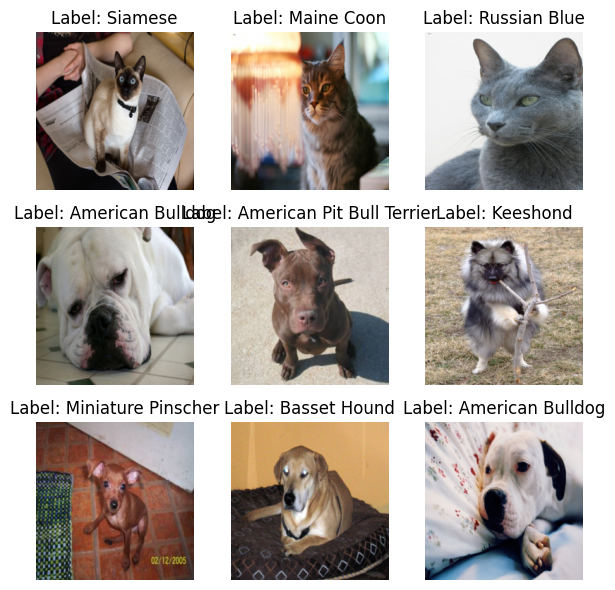

In [7]:
show_multiple_images(trainloader)

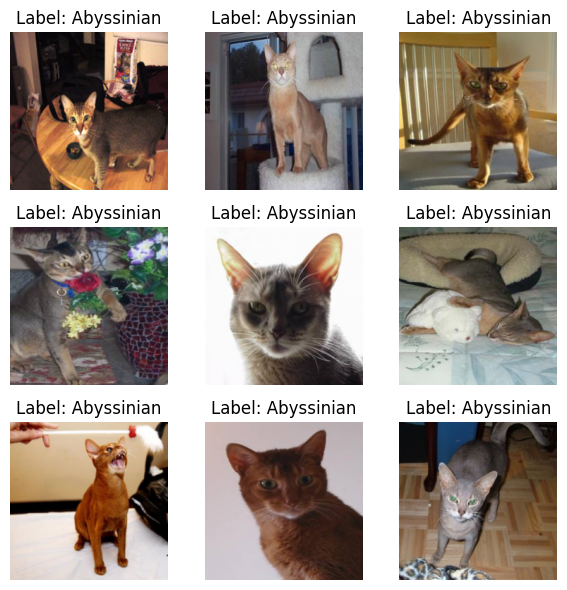

In [8]:
show_multiple_images(testloader)

In [9]:
import torch
import torch.nn as nn

# 1. BasicBlock (ResNet-34 / PlainNet-34용)
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None, use_skip_connection=True):
        super(BasicBlock, self).__init__()
        self.use_skip_connection = use_skip_connection # 스위치 저장

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 스위치가 켜져 있을 때만 Skip Connection 적용
        if self.use_skip_connection:
            if self.downsample is not None:
                identity = self.downsample(x)
            out += identity

        out = self.relu(out)
        return out

# 2. Bottleneck (ResNet-50 / PlainNet-50용)
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None, use_skip_connection=True):
        super(Bottleneck, self).__init__()
        self.use_skip_connection = use_skip_connection # 스위치 저장

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        # 스위치가 켜져 있을 때만 Skip Connection 적용
        if self.use_skip_connection:
            if self.downsample is not None:
                identity = self.downsample(x)
            out += identity

        out = self.relu(out)
        return out

In [10]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=37, use_skip_connection=True):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.use_skip_connection = use_skip_connection # 전체 모델 설정 저장

        # Stem (입력 부분)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Layers
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        # 가중치 초기화
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None

        # PlainNet일 경우 downsample 레이어도 사실상 필요 없지만,
        # ResNet 구조와 파라미터 수를 비슷하게 맞추거나 코드 호환성을 위해
        # downsample 계산 로직은 유지하되, 블록 내부에서 사용 여부만 결정합니다.
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        # 블록 생성 시 use_skip_connection 플래그 전달
        layers.append(block(self.in_channels, out_channels, stride, downsample, use_skip_connection=self.use_skip_connection))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels, use_skip_connection=self.use_skip_connection))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [11]:
def resnet34(num_classes=37):
    """Skip Connection이 있는 ResNet-34"""
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_skip_connection=True)

def resnet50(num_classes=37):
    """Skip Connection이 있는 ResNet-50"""
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes, use_skip_connection=True)

def build_plainnet(model_name, num_classes=37):
    """
    Skip Connection이 없는 PlainNet 생성 함수
    model_name: 'plain34' or 'plain50'
    """
    if model_name == 'plain34':
        return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_skip_connection=False)
    elif model_name == 'plain50':
        return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes, use_skip_connection=False)
    else:
        raise ValueError("Choose model_name between 'plain34' and 'plain50'")

# === 사용 예시 및 확인 ===
if __name__ == "__main__":
    # 입력 이미지 (224, 224, 3) -> Batch size 포함 (1, 3, 224, 224)
    dummy_input = torch.randn(1, 3, 224, 224)

    # 1. ResNet-50 생성 및 확인
    model_resnet50 = resnet50()
    output_resnet = model_resnet50(dummy_input)
    print(f"[ResNet-50] Output Shape: {output_resnet.shape}") # (1, 37)

    # 2. PlainNet-50 생성 및 확인
    model_plain50 = build_plainnet('plain50')
    output_plain = model_plain50(dummy_input)
    print(f"[PlainNet-50] Output Shape: {output_plain.shape}") # (1, 37)

    # 3. PlainNet-34 생성 및 확인
    model_plain34 = build_plainnet('plain34')
    output_plain34 = model_plain34(dummy_input)
    print(f"[PlainNet-34] Output Shape: {output_plain34.shape}") # (1, 37)

    print("\n성공적으로 모든 모델이 생성되었습니다!")

[ResNet-50] Output Shape: torch.Size([1, 37])
[PlainNet-50] Output Shape: torch.Size([1, 37])
[PlainNet-34] Output Shape: torch.Size([1, 37])

성공적으로 모든 모델이 생성되었습니다!


In [12]:
EPOCH = 15
BATCH_SIZE = 256

In [13]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

# 시간 측정 시작
current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# [수정 1] 데이터셋 클래스 개수에 맞게 num_classes 설정 (예: 37)
model_resnet34 = resnet34(num_classes=37).to(device)

# ResNet 파라미터 학습 가능하도록 설정
for param in model_resnet34.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_resnet34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

resnet34_train_losses = []
resnet34_val_accuracies = []

print("ResNet-34 학습 시작...")

for epoch in range(EPOCH):
    # --- 학습 (Train) ---
    model_resnet34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model_resnet34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f'[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

    # 에포크 당 학습 결과 저장
    # (정확한 로깅을 위해 마지막 배치의 loss 대신 전체 평균을 쓰는 것이 좋으나, 작성하신 코드 스타일을 유지했습니다)
    resnet34_epoch_loss = loss.item()
    resnet34_train_acc = 100 * correct / total

    # [수정 2] 오타 수정 (appendd -> append)
    resnet34_train_losses.append(resnet34_epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCH}] Train Loss: {resnet34_epoch_loss:.4f}, Train Acc: {resnet34_train_acc:.2f}%")

    # --- 검증 (Validation) ---
    model_resnet34.eval() # 평가 모드 전환
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_resnet34(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet34_val_accuracies.append(val_acc)

    print(f"Epoch [{epoch + 1}/{EPOCH}] Validation Acc: {val_acc:.2f}%")

print(f"Total Training time: {time.time() - current_time:.2f} seconds")

ResNet-34 학습 시작...
[Epoch 1, Batch   100] loss: 3.629
Epoch [1/15] Train Loss: 3.5558, Train Acc: 3.56%
Epoch [1/15] Validation Acc: 3.35%
[Epoch 2, Batch   100] loss: 3.540
Epoch [2/15] Train Loss: 3.4836, Train Acc: 5.27%
Epoch [2/15] Validation Acc: 5.45%
[Epoch 3, Batch   100] loss: 3.454
Epoch [3/15] Train Loss: 3.3185, Train Acc: 7.93%
Epoch [3/15] Validation Acc: 7.71%
[Epoch 4, Batch   100] loss: 3.367
Epoch [4/15] Train Loss: 3.2953, Train Acc: 9.76%
Epoch [4/15] Validation Acc: 6.73%
[Epoch 5, Batch   100] loss: 3.253
Epoch [5/15] Train Loss: 3.2422, Train Acc: 11.71%
Epoch [5/15] Validation Acc: 9.40%
[Epoch 6, Batch   100] loss: 3.151
Epoch [6/15] Train Loss: 2.9135, Train Acc: 14.43%
Epoch [6/15] Validation Acc: 11.91%
[Epoch 7, Batch   100] loss: 3.007
Epoch [7/15] Train Loss: 2.8589, Train Acc: 17.34%
Epoch [7/15] Validation Acc: 11.17%
[Epoch 8, Batch   100] loss: 2.856
Epoch [8/15] Train Loss: 3.0449, Train Acc: 21.14%
Epoch [8/15] Validation Acc: 10.22%
[Epoch 9, Batc

In [14]:
# === PlainNet-34 학습 ===

print("PlainNet-34 학습 시작...")
model_plain34 = build_plainnet('plain34', num_classes=37).to(device)

# PlainNet 파라미터 설정
optimizer = optim.SGD(model_plain34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

plain34_train_losses = []
plain34_val_accuracies = []

for epoch in range(EPOCH):
    # --- 학습 (Train) ---
    model_plain34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_plain34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 정확도 계산
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # 에포크 당 평균 Loss 저장 (이전 코드보다 조금 더 정확하게 수정함)
    epoch_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    plain34_train_losses.append(epoch_loss)

    print(f"[PlainNet] Epoch [{epoch+1}/{EPOCH}] Loss: {epoch_loss:.4f}, Acc: {train_acc:.2f}%")

    # --- 검증 (Validation) ---
    model_plain34.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_plain34(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    plain34_val_accuracies.append(val_acc)

    print(f"[PlainNet] Epoch [{epoch+1}/{EPOCH}] Val Acc: {val_acc:.2f}%")

print("PlainNet 학습 완료!")

PlainNet-34 학습 시작...
[PlainNet] Epoch [1/15] Loss: 3.6189, Acc: 2.96%
[PlainNet] Epoch [1/15] Val Acc: 2.94%
[PlainNet] Epoch [2/15] Loss: 3.5716, Acc: 3.94%
[PlainNet] Epoch [2/15] Val Acc: 4.25%
[PlainNet] Epoch [3/15] Loss: 3.5493, Acc: 4.59%
[PlainNet] Epoch [3/15] Val Acc: 4.52%
[PlainNet] Epoch [4/15] Loss: 3.5268, Acc: 4.84%
[PlainNet] Epoch [4/15] Val Acc: 4.20%
[PlainNet] Epoch [5/15] Loss: 3.5058, Acc: 4.97%
[PlainNet] Epoch [5/15] Val Acc: 5.18%
[PlainNet] Epoch [6/15] Loss: 3.4898, Acc: 5.43%
[PlainNet] Epoch [6/15] Val Acc: 4.80%
[PlainNet] Epoch [7/15] Loss: 3.4734, Acc: 6.36%
[PlainNet] Epoch [7/15] Val Acc: 5.81%
[PlainNet] Epoch [8/15] Loss: 3.4530, Acc: 6.60%
[PlainNet] Epoch [8/15] Val Acc: 5.78%
[PlainNet] Epoch [9/15] Loss: 3.4290, Acc: 6.93%
[PlainNet] Epoch [9/15] Val Acc: 6.54%
[PlainNet] Epoch [10/15] Loss: 3.3904, Acc: 7.96%
[PlainNet] Epoch [10/15] Val Acc: 7.36%
[PlainNet] Epoch [11/15] Loss: 3.3359, Acc: 9.16%
[PlainNet] Epoch [11/15] Val Acc: 7.74%
[PlainN

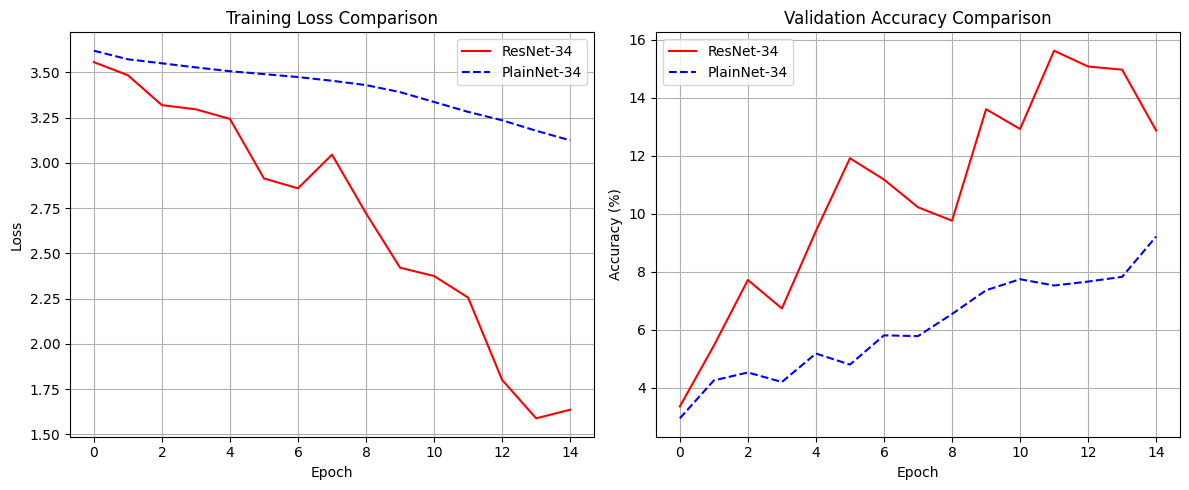

In [15]:
import matplotlib.pyplot as plt

# 그래프 크기 설정
plt.figure(figsize=(12, 5))

# 1. 학습 Loss 비교 (낮을수록 좋음)
plt.subplot(1, 2, 1)
plt.plot(resnet34_train_losses, label='ResNet-34', color='red')
plt.plot(plain34_train_losses, label='PlainNet-34', color='blue', linestyle='--')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. 검증 정확도 비교 (높을수록 좋음)
plt.subplot(1, 2, 2)
plt.plot(resnet34_val_accuracies, label='ResNet-34', color='red')
plt.plot(plain34_val_accuracies, label='PlainNet-34', color='blue', linestyle='--')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
print("=== ResNet-50 학습 시작 ===")

# 1. 모델 생성 (클래스 37개 기준)
model_resnet50 = resnet50(num_classes=37).to(device)

# 2. 설정 (Optimizer, Loss)
optimizer = optim.SGD(model_resnet50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# 3. 결과 저장용 리스트
resnet50_train_losses = []
resnet50_val_accuracies = []

for epoch in range(EPOCH):
    # --- 학습 (Train) ---
    model_resnet50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 정확도 계산을 위한 예측
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # 에포크 당 평균 Loss
    epoch_loss = running_loss / len(trainloader)
    resnet50_train_losses.append(epoch_loss)

    train_acc = 100 * correct / total
    print(f"[ResNet-50] Epoch [{epoch+1}/{EPOCH}] Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.2f}%")

    # --- 검증 (Validation) ---
    model_resnet50.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_resnet50(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet50_val_accuracies.append(val_acc)
    print(f"            Validation Acc: {val_acc:.2f}%")

print("ResNet-50 학습 완료!")

=== ResNet-50 학습 시작 ===
[ResNet-50] Epoch [1/15] Loss: 3.7645, Train Acc: 2.85%
            Validation Acc: 3.13%
[ResNet-50] Epoch [2/15] Loss: 3.7189, Train Acc: 3.51%
            Validation Acc: 2.97%
[ResNet-50] Epoch [3/15] Loss: 3.7207, Train Acc: 4.51%
            Validation Acc: 3.54%
[ResNet-50] Epoch [4/15] Loss: 3.6626, Train Acc: 4.43%
            Validation Acc: 4.61%
[ResNet-50] Epoch [5/15] Loss: 3.6131, Train Acc: 5.24%
            Validation Acc: 5.15%
[ResNet-50] Epoch [6/15] Loss: 3.5744, Train Acc: 5.92%
            Validation Acc: 5.56%
[ResNet-50] Epoch [7/15] Loss: 3.5286, Train Acc: 7.04%
            Validation Acc: 5.23%
[ResNet-50] Epoch [8/15] Loss: 3.4716, Train Acc: 7.72%
            Validation Acc: 6.57%
[ResNet-50] Epoch [9/15] Loss: 3.3916, Train Acc: 9.95%
            Validation Acc: 6.84%
[ResNet-50] Epoch [10/15] Loss: 3.3176, Train Acc: 10.92%
            Validation Acc: 8.20%
[ResNet-50] Epoch [11/15] Loss: 3.2514, Train Acc: 12.80%
            Vali

In [17]:
print("=== PlainNet-50 학습 시작 ===")

# 1. 모델 생성 (Skip Connection 끈 버전)
model_plain50 = build_plainnet('plain50', num_classes=37).to(device)

# 2. 설정 (새로운 모델이므로 Optimizer 새로 선언 필수)
optimizer = optim.SGD(model_plain50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# 3. 결과 저장용 리스트
plain50_train_losses = []
plain50_val_accuracies = []

for epoch in range(EPOCH):
    # --- 학습 (Train) ---
    model_plain50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_plain50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # 에포크 당 평균 Loss
    epoch_loss = running_loss / len(trainloader)
    plain50_train_losses.append(epoch_loss)

    train_acc = 100 * correct / total
    print(f"[PlainNet-50] Epoch [{epoch+1}/{EPOCH}] Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.2f}%")

    # --- 검증 (Validation) ---
    model_plain50.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_plain50(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    plain50_val_accuracies.append(val_acc)
    print(f"              Validation Acc: {val_acc:.2f}%")

print("PlainNet-50 학습 완료!")

=== PlainNet-50 학습 시작 ===
[PlainNet-50] Epoch [1/15] Loss: 3.6421, Train Acc: 2.77%
              Validation Acc: 2.45%
[PlainNet-50] Epoch [2/15] Loss: 3.6297, Train Acc: 2.77%
              Validation Acc: 3.13%
[PlainNet-50] Epoch [3/15] Loss: 3.6363, Train Acc: 2.31%
              Validation Acc: 2.81%
[PlainNet-50] Epoch [4/15] Loss: 3.6273, Train Acc: 2.91%
              Validation Acc: 2.83%
[PlainNet-50] Epoch [5/15] Loss: 3.6259, Train Acc: 2.83%
              Validation Acc: 3.05%
[PlainNet-50] Epoch [6/15] Loss: 3.6201, Train Acc: 2.85%
              Validation Acc: 3.35%
[PlainNet-50] Epoch [7/15] Loss: 3.6146, Train Acc: 3.29%
              Validation Acc: 3.65%
[PlainNet-50] Epoch [8/15] Loss: 3.6167, Train Acc: 3.29%
              Validation Acc: 3.16%
[PlainNet-50] Epoch [9/15] Loss: 3.6071, Train Acc: 3.51%
              Validation Acc: 3.00%
[PlainNet-50] Epoch [10/15] Loss: 3.6018, Train Acc: 3.94%
              Validation Acc: 2.73%
[PlainNet-50] Epoch [11/15] Loss:

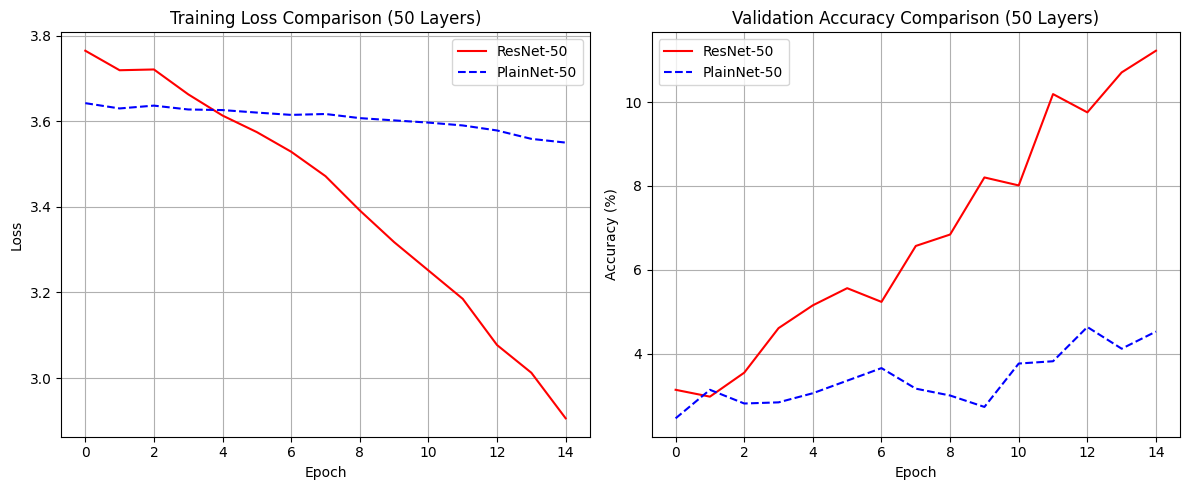

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. 학습 Loss 비교 (왼쪽 그래프)
plt.subplot(1, 2, 1)
plt.plot(resnet50_train_losses, label='ResNet-50', color='red')
plt.plot(plain50_train_losses, label='PlainNet-50', color='blue', linestyle='--')
plt.title('Training Loss Comparison (50 Layers)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. 검증 Accuracy 비교 (오른쪽 그래프)
plt.subplot(1, 2, 2)
plt.plot(resnet50_val_accuracies, label='ResNet-50', color='red')
plt.plot(plain50_val_accuracies, label='PlainNet-50', color='blue', linestyle='--')
plt.title('Validation Accuracy Comparison (50 Layers)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 회고

1. 생각보다 논문을 보고 ResNet모델을 구성하려하니 너무 많은것이 필요하다는것을 느끼고 생성형AI의 도움이 없었다면 사실 만들기 어려웠을것같다.